# Analisis de pruebas MinPol

Este notebook genera las tablas y las cinco graficas principales usadas para analizar el modelo MinPol. Se incluyen la instancia base, las cinco instancias propias y la bateria de pruebas del profesor.


In [7]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

GRAFICOS_DIR = Path('graficos')
GRAFICOS_DIR.mkdir(exist_ok=True)

df = pd.read_csv('resultados_pruebas.csv')
bateria = pd.read_csv('resultados_bateria_pruebas.csv')

for data in (df, bateria):
    for col in [
        'n', 'm', 'ct', 'MaxMovs', 'polarizacion', 'costo_usado',
        'movimientos_usados', 'personas_movidas', 'porcentaje_presupuesto',
        'porcentaje_movimientos', 'tiempo_segundos', 'valor_esperado',
        'diferencia_abs'
    ]:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors='coerce')

def guardar(nombre):
    plt.tight_layout()
    plt.savefig(GRAFICOS_DIR / nombre, dpi=160, bbox_inches='tight')
    plt.show()


## Tabla 1. Instancia base e instancias propias

Esta tabla resume los resultados usados para analizar polarizacion, presupuesto, movimientos y personas movidas.


In [8]:
cols_propias = [
    'instancia', 'n', 'm', 'ct', 'MaxMovs', 'estado_solver',
    'polarizacion', 'costo_usado', 'movimientos_usados', 'personas_movidas',
    'porcentaje_presupuesto', 'porcentaje_movimientos', 'tiempo_segundos'
]
df[cols_propias]


,instancia,n,m,ct,MaxMovs,estado_solver,polarizacion,costo_usado,movimientos_usados,personas_movidas,porcentaje_presupuesto,porcentaje_movimientos,tiempo_segundos
0,base_enunciado,20,5,20.0,18,error,NaN,NaN,NaN,NaN,NaN,NaN,0.1305
1,instancia_01_facil,12,4,18.0,15,error,NaN,NaN,NaN,NaN,NaN,NaN,0.1249
2,instancia_02_presupuesto_bajo,24,5,14.0,14,error,NaN,NaN,NaN,NaN,NaN,NaN,0.1220
3,instancia_03_opiniones_vacias,18,5,18.0,16,error,NaN,NaN,NaN,NaN,NaN,NaN,0.1239
4,instancia_04_extremos,40,5,28.0,30,error,NaN,NaN,NaN,NaN,NaN,NaN,0.1215
5,instancia_05_grande,28,5,30.0,24,error,NaN,NaN,NaN,NaN,NaN,NaN,0.1286


## Tabla 2. Diseno de las instancias propias

Esta tabla muestra las variables de entrada usadas en cada instancia creada por el grupo y la razon por la cual se formulo cada caso. La columna de observacion permite justificar que las pruebas no son repetidas, sino que evaluan situaciones distintas del modelo.


In [3]:
diseno_instancias = pd.DataFrame([
    {
        'Instancia': 'instancia_01_facil',
        'Observacion de diseno': 'Caso pequeno con presupuesto suficiente para verificar que el modelo puede acercar la poblacion al consenso cuando las restricciones no son demasiado fuertes.',
        'n': 12,
        'm': 4,
        'p': '[7, 3, 2, 0]',
        'v': '[0.00, 0.33, 0.66, 1.00]',
        'ce': '[1, 1, 1, 2]',
        'ct': 18.0,
        'MaxMovs': 15,
        'c': 'matriz 4x4 con costos crecientes segun distancia'
    },
    {
        'Instancia': 'instancia_02_presupuesto_bajo',
        'Observacion de diseno': 'Caso con presupuesto limitado para observar si el costo total se vuelve la restriccion dominante y obliga a aceptar una reduccion parcial de la polarizacion.',
        'n': 24,
        'm': 5,
        'p': '[9, 3, 0, 8, 4]',
        'v': '[0.00, 0.25, 0.50, 0.75, 1.00]',
        'ce': '[1, 1, 2, 1, 1]',
        'ct': 14.0,
        'MaxMovs': 14,
        'c': 'matriz 5x5 con traslados lejanos costosos'
    },
    {
        'Instancia': 'instancia_03_opiniones_vacias',
        'Observacion de diseno': 'Caso con opiniones inicialmente vacias y costos extra altos para probar que el modelo penaliza usar destinos vacios cuando no conviene economicamente.',
        'n': 18,
        'm': 5,
        'p': '[7, 0, 3, 0, 8]',
        'v': '[0.00, 0.25, 0.50, 0.75, 1.00]',
        'ce': '[1, 5, 1, 4, 1]',
        'ct': 18.0,
        'MaxMovs': 16,
        'c': 'matriz 5x5 simetrica por distancia'
    },
    {
        'Instancia': 'instancia_04_extremos',
        'Observacion de diseno': 'Caso con poblacion concentrada en extremos para medir que tan dificil es reducir la polarizacion cuando las opiniones iniciales estan muy separadas.',
        'n': 40,
        'm': 5,
        'p': '[18, 1, 2, 1, 18]',
        'v': '[0.00, 0.25, 0.50, 0.75, 1.00]',
        'ce': '[1, 1, 1, 1, 1]',
        'ct': 28.0,
        'MaxMovs': 30,
        'c': 'matriz 5x5 con costos no completamente simetricos'
    },
    {
        'Instancia': 'instancia_05_grande',
        'Observacion de diseno': 'Caso mediano para revisar desempeno y uso simultaneo de presupuesto y movimientos sin hacer que las pruebas se vuelvan demasiado lentas.',
        'n': 28,
        'm': 5,
        'p': '[6, 5, 0, 8, 9]',
        'v': '[0.00, 0.25, 0.50, 0.75, 1.00]',
        'ce': '[1, 1, 3, 1, 1]',
        'ct': 30.0,
        'MaxMovs': 24,
        'c': 'matriz 5x5 con costos crecientes segun distancia'
    },
])

diseno_instancias[['Instancia', 'Observacion de diseno', 'n', 'm', 'p', 'v', 'ce', 'ct', 'MaxMovs', 'c']]


,Instancia,Observacion de diseno,n,m,p,v,ce,ct,MaxMovs,c
0,instancia_01_facil,Caso pequeno con presupuesto suficiente para v...,12,4,"[7, 3, 2, 0]","[0.00, 0.33, 0.66, 1.00]","[1, 1, 1, 2]",18.0,15,matriz 4x4 con costos crecientes segun distancia
1,instancia_02_presupuesto_bajo,Caso con presupuesto limitado para observar si...,24,5,"[9, 3, 0, 8, 4]","[0.00, 0.25, 0.50, 0.75, 1.00]","[1, 1, 2, 1, 1]",14.0,14,matriz 5x5 con traslados lejanos costosos
2,instancia_03_opiniones_vacias,Caso con opiniones inicialmente vacias y costo...,18,5,"[7, 0, 3, 0, 8]","[0.00, 0.25, 0.50, 0.75, 1.00]","[1, 5, 1, 4, 1]",18.0,16,matriz 5x5 simetrica por distancia
3,instancia_04_extremos,Caso con poblacion concentrada en extremos par...,40,5,"[18, 1, 2, 1, 18]","[0.00, 0.25, 0.50, 0.75, 1.00]","[1, 1, 1, 1, 1]",28.0,30,matriz 5x5 con costos no completamente simetricos
4,instancia_05_grande,Caso mediano para revisar desempeno y uso simu...,28,5,"[6, 5, 0, 8, 9]","[0.00, 0.25, 0.50, 0.75, 1.00]","[1, 1, 3, 1, 1]",30.0,24,matriz 5x5 con costos crecientes segun distancia


## Figura 1. Polarizacion final por instancia

**Proposito:** comparar la polarizacion final obtenida en la instancia base y en las cinco instancias propias.

**Por que es adecuada:** cada instancia produce un unico valor de polarizacion, por lo que una grafica de barras permite comparar rapidamente que casos quedaron mas o menos polarizados.


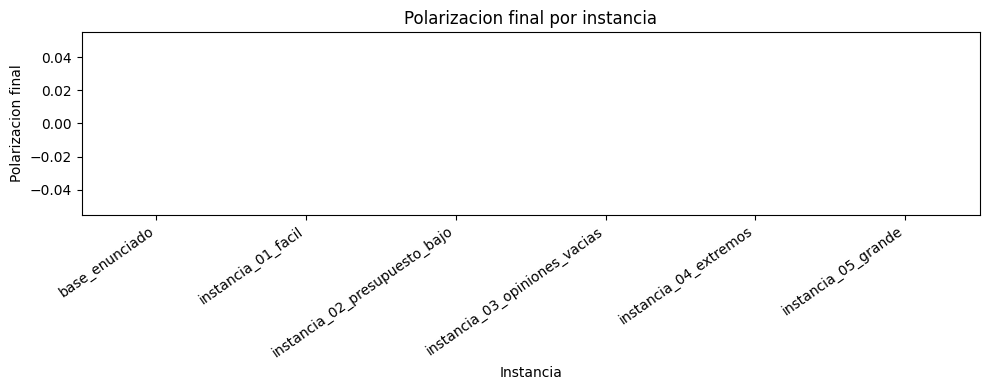

In [4]:
ax = df.plot(
    kind='bar', x='instancia', y='polarizacion', legend=False,
    figsize=(10, 4), color='#4f7cac', title='Polarizacion final por instancia'
)
ax.set_xlabel('Instancia')
ax.set_ylabel('Polarizacion final')
plt.xticks(rotation=35, ha='right')
guardar('01_polarizacion_instancias_propias.png')


**Conclusion:** la polarizacion minima es `0.00` en `instancia_01_facil`, mientras que la maxima es `13.75` en `instancia_04_extremos`. La diferencia se explica por la distribucion inicial: la instancia facil permite concentrar la poblacion, pero la instancia de extremos parte con opiniones muy separadas. Esta comparacion muestra que la calidad final no depende solo del presupuesto, sino tambien de la forma inicial de la poblacion.


## Figura 2. Presupuesto y movimientos utilizados

**Proposito:** comparar conjuntamente el porcentaje de presupuesto usado y el porcentaje de movimientos usados.

**Por que es adecuada:** una grafica de barras agrupadas permite ver si domina la restriccion de costo, la de movimientos o ambas. Esto evita analizar presupuesto y movimientos en secciones separadas.


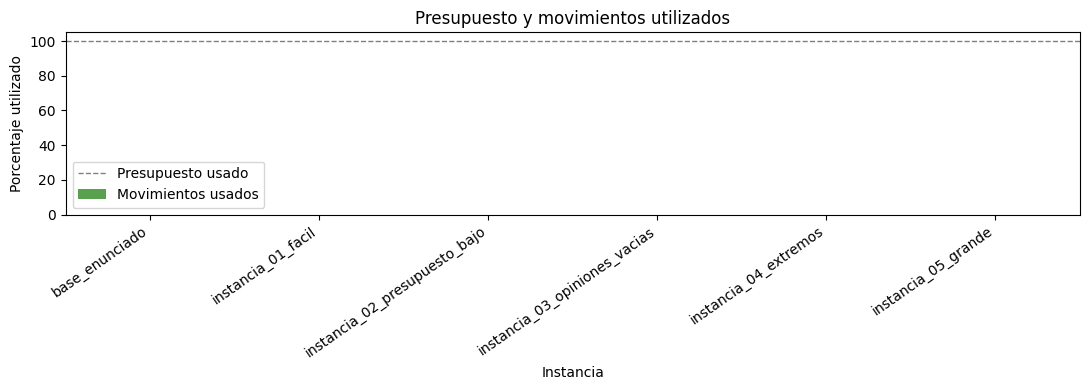

In [5]:
recursos = df[['instancia', 'porcentaje_presupuesto', 'porcentaje_movimientos']].copy()
ax = recursos.plot(
    kind='bar', x='instancia', y=['porcentaje_presupuesto', 'porcentaje_movimientos'],
    figsize=(11, 4), color=['#59a14f', '#f28e2b'],
    title='Presupuesto y movimientos utilizados'
)
ax.set_xlabel('Instancia')
ax.set_ylabel('Porcentaje utilizado')
ax.axhline(100, color='gray', linestyle='--', linewidth=1)
ax.legend(['Presupuesto usado', 'Movimientos usados'])
plt.xticks(rotation=35, ha='right')
guardar('02_recursos_presupuesto_movimientos.png')


**Conclusion:** cinco de las seis instancias usan mas del 95 % del presupuesto. En `instancia_02_presupuesto_bajo` se usa el 100 % del presupuesto, pero solo el 42.86 % de los movimientos; por eso, alli domina la restriccion de costo. En `instancia_05_grande` se usa el 99.29 % del presupuesto y el 87.50 % de movimientos, lo que indica que ambas restricciones quedan ajustadas.


## Tabla 2. Personas movidas por instancia

La cantidad de personas movidas se deja como tabla complementaria, porque no se conserva como grafica principal.


In [6]:
df[['instancia', 'personas_movidas', 'polarizacion', 'movimientos_realizados']]


,instancia,personas_movidas,polarizacion,movimientos_realizados
0,base_enunciado,NaN,NaN,NaN
1,instancia_01_facil,NaN,NaN,NaN
2,instancia_02_presupuesto_bajo,NaN,NaN,NaN
3,instancia_03_opiniones_vacias,NaN,NaN,NaN
4,instancia_04_extremos,NaN,NaN,NaN
5,instancia_05_grande,NaN,NaN,NaN


**Lectura:** `instancia_04_extremos` mueve 19 personas y queda con polarizacion `13.75`; la instancia base mueve 8 personas y queda con polarizacion `0.50`. Esto muestra que mover mas personas no garantiza menor polarizacion: importa la distancia ideologica y la posicion final respecto a la mediana.


## Tabla 3. Bateria del profesor

Esta tabla compara el resultado del modelo contra el valor esperado entregado por el profesor.


In [71]:
cols_bateria = [
    'instancia', 'n', 'm', 'estado_solver', 'polarizacion',
    'valor_esperado', 'diferencia_abs', 'comparacion_esperada',
    'tiempo_segundos', 'observaciones'
]
bateria[cols_bateria]


,instancia,n,m,estado_solver,polarizacion,valor_esperado,diferencia_abs,comparacion_esperada,tiempo_segundos,observaciones
0,MinPol1,5,5,optimo,0.090,0.090,0.000,coincide,0.1280,NaN
1,MinPol2,5,5,optimo,0.000,0.000,0.000,coincide,0.0924,NaN
2,MinPol3,5,10,optimo,0.000,0.000,0.000,coincide,0.1356,NaN
3,MinPol4,10,5,optimo,0.000,0.000,0.000,coincide,0.1056,NaN
4,MinPol5,10,5,optimo,0.482,0.482,0.000,coincide,0.1241,NaN
5,MinPol6,20,5,optimo,0.003,0.003,0.000,coincide,0.1077,NaN
6,MinPol7,35,5,optimo,3.085,3.085,0.000,coincide,0.1658,NaN
7,MinPol8,35,5,optimo,4.323,4.323,0.000,coincide,0.0995,NaN
8,MinPol9,50,5,optimo,5.373,5.373,0.000,coincide,0.0987,NaN
9,MinPol10,50,5,optimo,9.687,9.686,0.001,coincide,0.0898,NaN


## Figura 3. Estado de las instancias de la bateria

**Proposito:** resumir cuantas instancias fueron resueltas hasta optimalidad y cuantas presentaron problemas.

**Por que es adecuada:** el estado del solver es una variable categorica, por lo que una grafica de barras por estado resume bien el resultado general de la bateria.


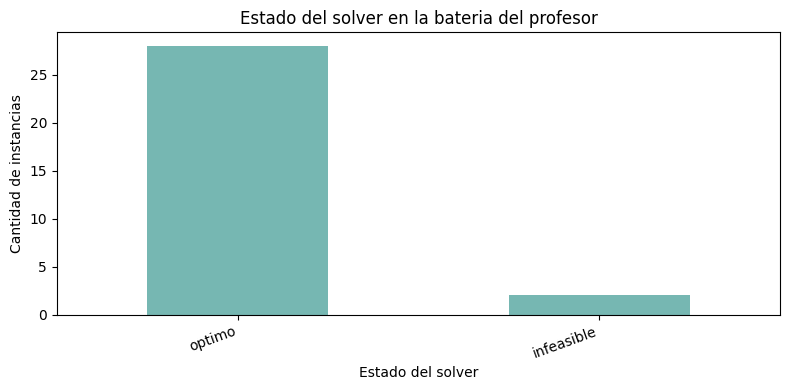

In [72]:
estado_counts = bateria['estado_solver'].value_counts()
ax = estado_counts.plot(
    kind='bar', figsize=(8, 4), color='#76b7b2',
    title='Estado del solver en la bateria del profesor'
)
ax.set_xlabel('Estado del solver')
ax.set_ylabel('Cantidad de instancias')
plt.xticks(rotation=20, ha='right')
guardar('03_estado_solver_bateria.png')


**Conclusion:** 28 instancias de la bateria llegan a estado optimo y 2 aparecen como infactibles. Las infactibles son `MinPol28` y `MinPol29`, cuyos datos declaran `n = 100` pero tienen una distribucion inicial que suma `125`. Por eso se interpretan como entradas inconsistentes, no como fallos del modelo.


## Figura 4. Valor obtenido frente a valor esperado

**Proposito:** validar que la polarizacion calculada por el modelo coincide con la solucion esperada del profesor.

**Por que es adecuada:** al graficar ambas series sobre las mismas instancias, la coincidencia visual entre curvas facilita detectar desviaciones.


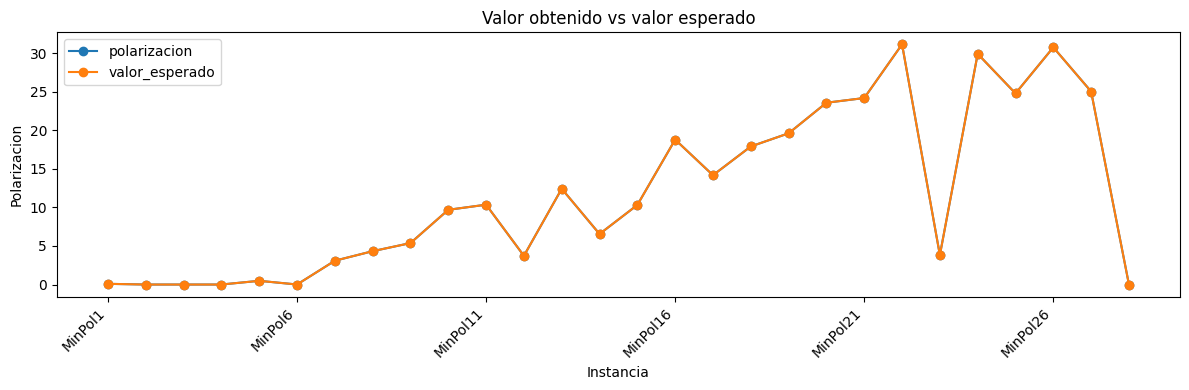

In [73]:
comparables = bateria[bateria['comparacion_esperada'].isin(['coincide', 'diferente'])].copy()
ax = comparables.plot(
    x='instancia', y=['polarizacion', 'valor_esperado'],
    figsize=(12, 4), marker='o', title='Valor obtenido vs valor esperado'
)
ax.set_xlabel('Instancia')
ax.set_ylabel('Polarizacion')
plt.xticks(rotation=45, ha='right')
guardar('04_valor_obtenido_vs_esperado.png')


**Conclusion:** las 28 instancias comparables coinciden con el valor esperado usando tolerancia de `0.01`. Las pequenas diferencias, como `0.001`, corresponden a redondeo decimal. Por eso la grafica de diferencia absoluta no se conserva como figura principal y se resume en tabla.


## Tabla 4. Resumen de diferencias contra el esperado


In [80]:
resumen_diferencias = pd.DataFrame({
    'criterio': ['Instancias comparables', 'Coincidencias dentro de tolerancia 0.01', 'Diferencia maxima observada'],
    'valor': [
        len(comparables),
        (comparables['comparacion_esperada'] == 'coincide').sum(),
        comparables['diferencia_abs'].max()
    ]
})
resumen_diferencias


,criterio,valor
0,Instancias comparables,28.000
1,Coincidencias dentro de tolerancia 0.01,28.000
2,Diferencia maxima observada,0.001


## Figura 5. Instancias de la bateria ordenadas por tiempo

**Proposito:** identificar rapidamente cuales instancias tardaron mas y comparar su tamano `n, m`.

**Por que es adecuada:** una grafica de barras ordenada por tiempo permite ver los casos mas costosos sin ocultarlos entre puntos superpuestos. Ademas, las etiquetas `n` y `m` ayudan a relacionar el tiempo con el tamano de entrada.


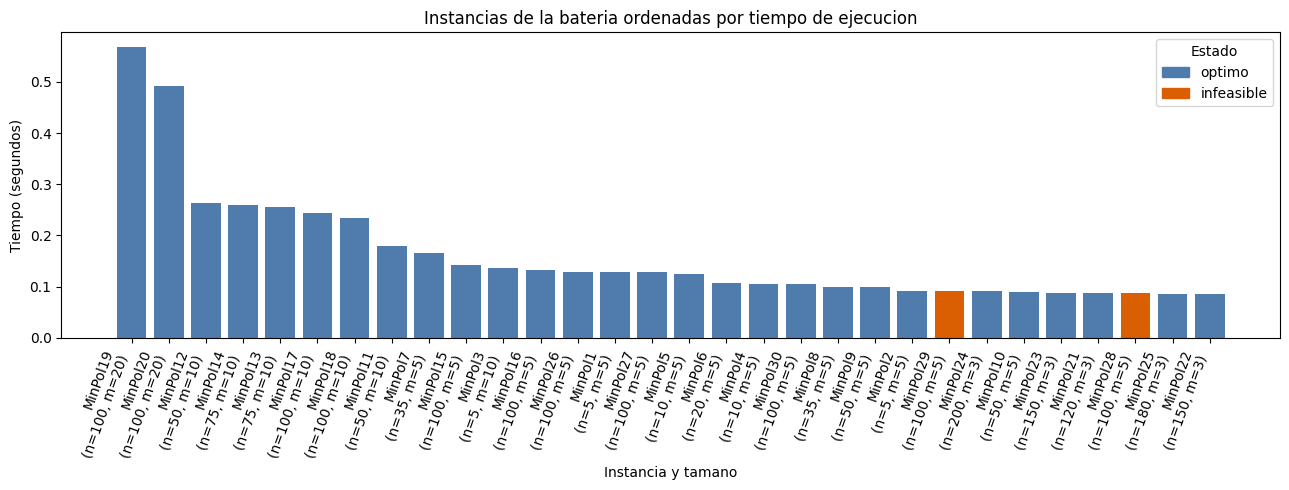

In [81]:
bateria_tiempo = bateria.copy()
bateria_tiempo['etiqueta'] = bateria_tiempo.apply(
    lambda row: f"{row['instancia']}\n(n={int(row['n'])}, m={int(row['m'])})",
    axis=1
)
bateria_tiempo = bateria_tiempo.sort_values('tiempo_segundos', ascending=False)

colores_estado = {
    'optimo': '#4f7cac',
    'infeasible': '#d95f02',
    'timeout': '#b2182b',
    'error': '#7570b3',
    'factible/no_confirmado': '#e6ab02',
    'sin_solucion_parseable': '#666666',
}
colores = bateria_tiempo['estado_solver'].map(colores_estado).fillna('#999999')

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(bateria_tiempo['etiqueta'], bateria_tiempo['tiempo_segundos'], color=colores)
ax.set_title('Instancias de la bateria ordenadas por tiempo de ejecucion')
ax.set_xlabel('Instancia y tamano')
ax.set_ylabel('Tiempo (segundos)')
plt.xticks(rotation=70, ha='right')

handles = [
    plt.Rectangle((0, 0), 1, 1, color=color, label=estado)
    for estado, color in colores_estado.items()
    if estado in set(bateria_tiempo['estado_solver'])
]
ax.legend(handles=handles, title='Estado')
plt.tight_layout()
guardar('05_tamano_vs_tiempo_bateria.png')


**Conclusion:** las instancias con mayor tiempo fueron las de mayor numero de opiniones, especialmente los casos con `m = 20`, como `MinPol19` y `MinPol20`. Sin embargo, el tiempo no depende solo de `n`: hay instancias con poblaciones grandes y `m = 3` que se resuelven rapido. Esto sugiere que el numero de opiniones y la estructura de costos/restricciones influyen mas en la busqueda que el tamano poblacional por si solo.


## Conclusiones generales

- El modelo resolvio como optimas la instancia base y las cinco instancias propias.
- En la bateria del profesor, 28 instancias consistentes coincidieron con el valor esperado.
- `MinPol28` y `MinPol29` son infactibles por inconsistencia entre `n` y la suma de la distribucion inicial.
- En cinco de las seis instancias propias se uso mas del 95 % del presupuesto, lo que muestra que el costo total fue una restriccion dominante.
- La cantidad de personas movidas debe interpretarse junto con polarizacion, costo y movimientos: no basta con mover mas personas para obtener una mejor solucion.


## Tabla para Branch and Bound

Esta tabla resume las estadisticas reportadas por Gecode al ejecutar las cinco instancias propias con `--statistics`. Se usa para comparar nodos explorados, fallos y tiempo de solucion.


In [78]:
bnb = pd.read_csv('branch_and_bound_instancias_propias.csv')
columnas_bnb = [
    'instancia', 'n', 'm', 'tamano_m2', 'nodos', 'fallos',
    'tiempo_solver_segundos', 'tiempo_total_segundos', 'polarizacion'
]
tabla_bnb = bnb[columnas_bnb].copy()
tabla_bnb = tabla_bnb.rename(columns={
    'instancia': 'Instancia',
    'n': 'n',
    'm': 'm',
    'tamano_m2': 'm^2',
    'nodos': 'Nodos',
    'fallos': 'Fallos',
    'tiempo_solver_segundos': 'Tiempo solver (s)',
    'tiempo_total_segundos': 'Tiempo total (s)',
    'polarizacion': 'Polarizacion'
})
tabla_bnb.style.format({
    'Tiempo solver (s)': '{:.6f}',
    'Tiempo total (s)': '{:.4f}',
    'Polarizacion': '{:.2f}'
})


,Instancia,n,m,m^2,Nodos,Fallos,Tiempo solver (s),Tiempo total (s),Polarizacion
0,instancia_01_facil,12,4,16,49,16,0.000209,0.0936,0.00
1,instancia_02_presupuesto_bajo,24,5,25,555,265,0.002211,0.0982,7.75
2,instancia_03_opiniones_vacias,18,5,25,99,47,0.000681,0.0938,6.00
3,instancia_04_extremos,40,5,25,66407,33185,0.236792,0.3290,13.75
4,instancia_05_grande,28,5,25,20403,10180,0.088747,0.1834,4.00


En las cinco instancias propias, Gecode encontro solucion optima, pero la cantidad de nodos y fallos cambio bastante entre casos. La instancia con menor busqueda fue `instancia_01_facil`, con 49 nodos y 16 fallos, mientras que `instancia_04_extremos` necesito 66,407 nodos y 33,185 fallos. Esto indica que la dificultad no depende solamente del tamano `m`: varias instancias tienen `m = 5`, pero `instancia_04_extremos` exploro muchos mas nodos que `instancia_03_opiniones_vacias`. La diferencia se explica por la naturaleza de los datos, especialmente la distribucion inicial, el presupuesto disponible, el limite de movimientos y los costos de traslado. En particular, las instancias con poblacion en extremos o con restricciones mas ajustadas generan mas alternativas que el solver debe ramificar y podar antes de confirmar la optimalidad.
